In [1]:
# Builds a daily chart for the SF shelter waitlist

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from datetime import datetime
import seaborn as sns
import re
import numpy as np

In [3]:
# seaborn styles
sns.set_style("whitegrid")

In [4]:
# compile regex for extracting date
extract_date = re.compile(r'(\d{4}-\d{2}-\d{2})')

In [5]:
df_list = []

for file in glob("waitlist_data/*.csv"):
    day = extract_date.search(file).group(0)
    df = pd.read_csv(file).assign( date = pd.to_datetime(day))
    df_list.append(df)

df = pd.concat(df_list).sort_values("date", ascending=False)

df.head(3)


,Position,Waitlist ID,SR #,Instructions,data_as_of,data_loaded_at,date
318,319,08221955JA,101001902348,NaN,2025/05/20 11:40:00 AM,2025/05/20 11:57:51 AM,2025-05-21
275,276,03201971CF,101001889935,NaN,2025/05/20 11:40:00 AM,2025/05/20 11:57:51 AM,2025-05-21
277,278,12011995CE,101001889430,NaN,2025/05/20 11:40:00 AM,2025/05/20 11:57:51 AM,2025-05-21


In [6]:

group_by_day = (
    df.set_index("date")
      .resample("D")["Waitlist ID"]
      .count()
      .replace(0, np.nan)
      .to_frame(name="Count")
      # .reset_index()
)

group_by_day.head()

,Count
date,
2024-05-16,108.0
2024-05-17,108.0
2024-05-18,NaN
2024-05-19,101.0
2024-05-20,107.0


<Axes: title={'center': 'Waitlist Count by Day'}, xlabel='Date', ylabel='Count'>

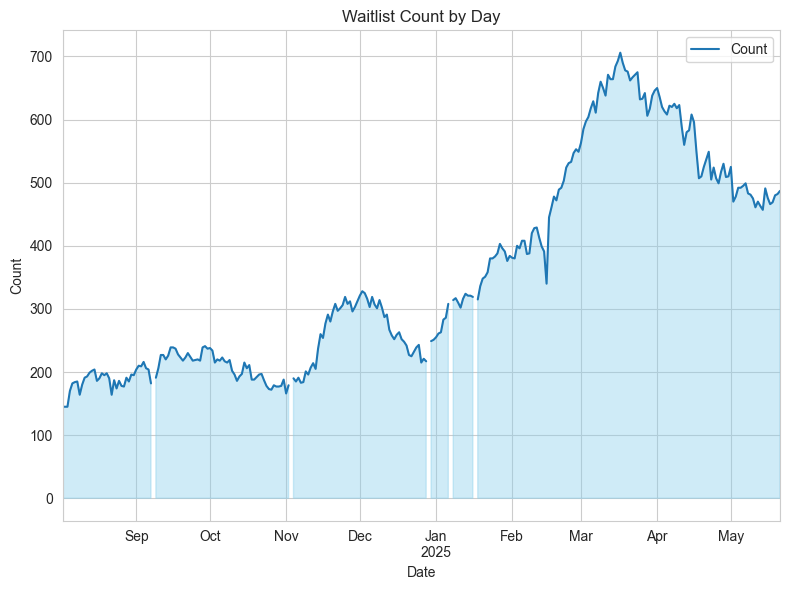

In [ ]:
ax = (
    group_by_day.loc[ lambda x: x.index > pd.Timestamp("2024-08-01")].plot(
        # x = "date",
        y = "Count",
        title="Waitlist Count by Day",
        xlabel="Date",
        ylabel="Count",
        figsize=(8, 6)
))

ax.fill_between(group_by_day.index, group_by_day['Count'], color='skyblue', alpha=0.4)

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("images/waitlist_count_by_day.png")
ax

---
---
---